# diffLLT — Differentiable LLT Shape Optimisation

Optimise a wing's Kulfan CST airfoil shape to maximise **CL/CD** at a fixed set of
operating points, using exact gradients through the 3D nonlinear Lifting-Line Theory
solver via the Implicit Function Theorem.

Background: `diffLLT/README.md` · `methods/3d_nonlinear_llt_method.md`

In [29]:
# Must be set BEFORE torch is imported.
# On MPS, torch.linalg.solve (used in the IFT backward) falls back to CPU.
import os
os.environ.setdefault('PYTORCH_ENABLE_MPS_FALLBACK', '1')

'1'

In [30]:
import sys, warnings
sys.path.insert(0, '..')   # AEROCOD root on sys.path
warnings.filterwarnings('ignore')

import torch
import numpy as np
import matplotlib.pyplot as plt

from diffLLT.core import Wing, AirfoilParams, DiffLLTEvaluator, ShapeOptimiser

## 1 · Load wing geometry

`Wing.from_yaml` reads the `plane.wing` block from the existing config and
precomputes the LLT influence matrices once.

In [31]:
wing = Wing.from_yaml('../conf/test.yaml')
print(wing)
print(f'  panels : {wing.n_pan}')
print(f'  device : {wing.device}')

Wing(n_pan=12, span=0.840 m, S=0.1008 m², cbar=0.1226 m, device=mps)
  panels : 12
  device : mps


## 2 · Define operating points

Polar sweep: AoA from −2° to 10°, constant airspeed 10 m/s.  
All points evaluated **simultaneously** in one batched LLT call.

In [32]:
alphas_deg = torch.linspace(-2.0, 10.0, 13, device=wing.device)  # (13,) degrees
velocities  = torch.full_like(alphas_deg, 10.0)                   # (13,) m/s
print('alpha sweep:', [round(a, 1) for a in alphas_deg.tolist()])

alpha sweep: [-2.0, -1.0, 0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]


## 3 · Baseline forward evaluation

Verify the forward pass and inspect the baseline CL, CD, CM polar.

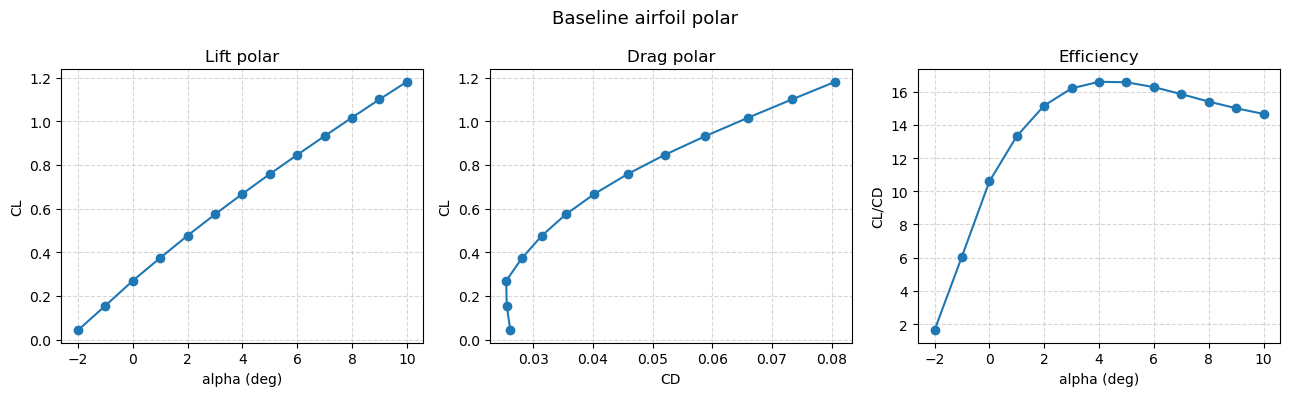

Baseline  mean CL/CD = 13.33   peak CL/CD = 16.59


In [33]:
evaluator = DiffLLTEvaluator(wing)
airfoil   = AirfoilParams.from_yaml('../conf/test.yaml', wing.device, requires_grad=False)

with torch.no_grad():
    result = evaluator(alphas_deg, velocities, airfoil)

cl  = result.CL.cpu().numpy()
cd  = result.CD.cpu().numpy()
aoa = alphas_deg.cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].plot(aoa, cl, 'o-');     axes[0].set(xlabel='alpha (deg)', ylabel='CL',    title='Lift polar')
axes[1].plot(cd,  cl, 'o-');     axes[1].set(xlabel='CD',          ylabel='CL',    title='Drag polar')
axes[2].plot(aoa, cl/cd, 'o-'); axes[2].set(xlabel='alpha (deg)', ylabel='CL/CD', title='Efficiency')
for ax in axes: ax.grid(True, linestyle='--', alpha=0.5)
plt.suptitle('Baseline airfoil polar', fontsize=13)
plt.tight_layout(); plt.show()
print(f'Baseline  mean CL/CD = {(cl/cd).mean():.2f}   peak CL/CD = {(cl/cd).max():.2f}')


## 4 · Gradient check

Confirm that one `.backward()` propagates non-zero gradients to the airfoil weights.

In [34]:
# Use a fresh copy with requires_grad=True for the gradient check
airfoil_grad = AirfoilParams.from_yaml('../conf/test.yaml', wing.device, requires_grad=True)

r2   = evaluator(alphas_deg, velocities, airfoil_grad)
loss = -(r2.CL / r2.CD.clamp(min=1e-5)).mean()
loss.backward()

print('upper.grad:', [round(x, 4) for x in airfoil_grad.upper.grad.tolist()])
assert airfoil_grad.upper.grad.abs().sum() > 0, 'Gradient is zero!'
print('Gradient check PASSED.')


upper.grad: [-2.7021, -13.3782, -13.842, 0.5252, 13.2635, 12.9406, 4.8685, -0.9068]
Gradient check PASSED.


## 5 · Cost function

Minimise **−mean(CL/CD)** over the polar sweep.  
Any callable `cost_fn(CL, CD, CM) -> scalar Tensor` works.

In [35]:
def cost_fn(CL: torch.Tensor, CD: torch.Tensor, CM: torch.Tensor) -> torch.Tensor:
    """Maximise mean aerodynamic efficiency."""
    return -(CL / CD.clamp(min=1e-5)).mean()

## 6 · Shape optimisation (root + tip)

Root and tip Kulfan weights are optimised **independently** with linear spanwise
interpolation in between — identical to the full pipeline's 3D airfoil block.

`ShapeOptimiser.run` performs Adam gradient steps with:
- Augmented Lagrangian penalty: `mean(CL/CD) >= min_avg_clcd`
- Hard clamps on TE thickness and `upper ≥ lower + 0.05` (gap constraint) after each step
- ExponentialLR learning-rate decay


In [36]:
# Baseline: NACA4412 from config (root = tip identical → three identical sections)
airfoil_base = AirfoilParams.from_yaml('../conf/test.yaml', wing.device, requires_grad=False)
# Optimised: same warm-start from config, then root + tip optimised independently
airfoil_opt  = AirfoilParams.from_yaml('../conf/test.yaml', wing.device)

opt = ShapeOptimiser(
    evaluator,
    cost_fn,
    alphas_deg, velocities,
    lr=1e-3,          # Adam step size
    gamma=0.995,      # LR decay per iteration
    min_avg_clcd=2.0, # constraint lower bound
    rho_aug=1.0,      # penalty weight
    verbose=25,       # print frequency
)

opt.run(airfoil_opt, n_iters=500)
print('\nOptimisation complete.')


iter    0  loss=-13.3288  CL=0.6458  CD=0.04530  CL/CD=13.33  λ_conf=0.000  λ_clcd=0.000
iter   25  loss=-15.6670  CL=0.7241  CD=0.04655  CL/CD=15.67  λ_conf=0.000  λ_clcd=0.000
iter   50  loss=-16.0796  CL=0.7415  CD=0.04732  CL/CD=16.08  λ_conf=0.000  λ_clcd=0.000
iter   75  loss=-16.2348  CL=0.7579  CD=0.04806  CL/CD=16.23  λ_conf=0.000  λ_clcd=0.000
iter  100  loss=-16.3380  CL=0.7670  CD=0.04837  CL/CD=16.34  λ_conf=0.000  λ_clcd=0.000
iter  125  loss=-16.4184  CL=0.7725  CD=0.04851  CL/CD=16.42  λ_conf=0.000  λ_clcd=0.000
iter  150  loss=-16.4875  CL=0.7753  CD=0.04851  CL/CD=16.49  λ_conf=0.000  λ_clcd=0.000
iter  175  loss=-16.5489  CL=0.7769  CD=0.04843  CL/CD=16.55  λ_conf=0.000  λ_clcd=0.000
iter  200  loss=-16.6036  CL=0.7777  CD=0.04832  CL/CD=16.60  λ_conf=0.000  λ_clcd=0.000
iter  225  loss=-16.6523  CL=0.7781  CD=0.04820  CL/CD=16.65  λ_conf=0.000  λ_clcd=0.000
iter  250  loss=-16.6956  CL=0.7783  CD=0.04809  CL/CD=16.70  λ_conf=0.000  λ_clcd=0.000
iter  275  loss=-16.7

## 7 · Convergence plots

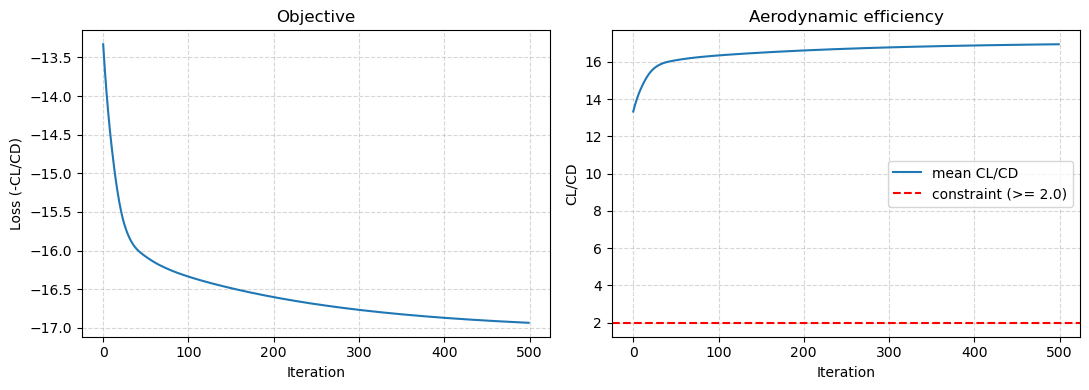

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(opt.history.loss)
axes[0].set(xlabel='Iteration', ylabel='Loss (-CL/CD)', title='Objective')
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].plot(opt.history.clcd, label='mean CL/CD')
axes[1].axhline(opt.min_avg_clcd, color='r', linestyle='--',
                label=f'constraint (>= {opt.min_avg_clcd})')
axes[1].set(xlabel='Iteration', ylabel='CL/CD', title='Aerodynamic efficiency')
axes[1].legend(); axes[1].grid(True, linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()

## 8 · Optimised polar vs baseline

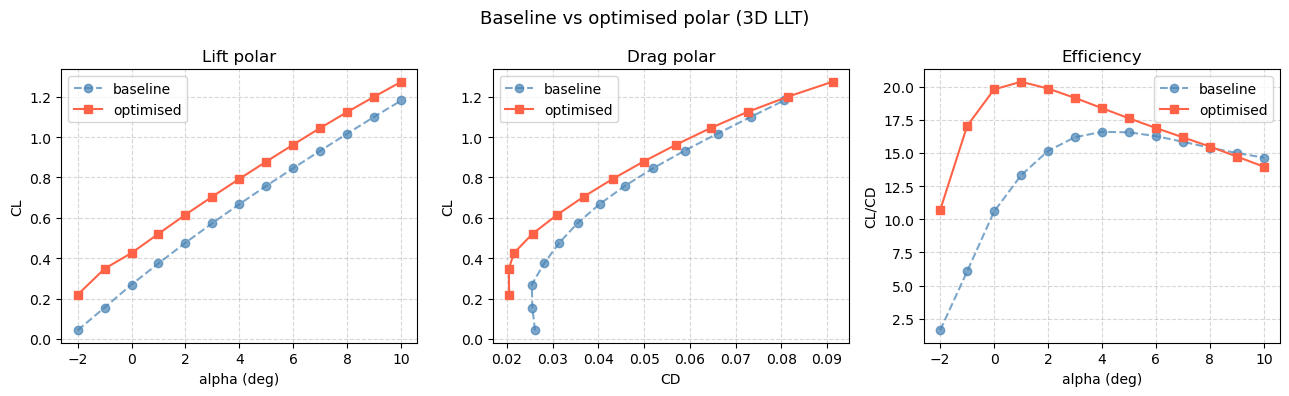

Baseline   mean CL/CD = 13.33   peak = 16.59
Optimised  mean CL/CD = 16.94   peak = 20.37


In [38]:
with torch.no_grad():
    r_base = evaluator(alphas_deg, velocities, airfoil_base)
    r_opt  = evaluator(alphas_deg, velocities, airfoil_opt)

cl_base = r_base.CL.cpu().numpy()
cd_base = r_base.CD.cpu().numpy()
cl_opt  = r_opt.CL.cpu().numpy()
cd_opt  = r_opt.CD.cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].plot(aoa, cl_base, 'o--', label='baseline', alpha=0.7, color='steelblue')
axes[0].plot(aoa, cl_opt,  's-',  label='optimised', color='tomato')
axes[0].set(xlabel='alpha (deg)', ylabel='CL', title='Lift polar'); axes[0].legend()

axes[1].plot(cd_base, cl_base, 'o--', label='baseline', alpha=0.7, color='steelblue')
axes[1].plot(cd_opt,  cl_opt,  's-',  label='optimised', color='tomato')
axes[1].set(xlabel='CD', ylabel='CL', title='Drag polar'); axes[1].legend()

axes[2].plot(aoa, cl_base/cd_base, 'o--', label='baseline', alpha=0.7, color='steelblue')
axes[2].plot(aoa, cl_opt /cd_opt,  's-',  label='optimised', color='tomato')
axes[2].set(xlabel='alpha (deg)', ylabel='CL/CD', title='Efficiency'); axes[2].legend()

for ax in axes: ax.grid(True, linestyle='--', alpha=0.5)
plt.suptitle('Baseline vs optimised polar (3D LLT)', fontsize=13)
plt.tight_layout(); plt.show()

print(f'Baseline   mean CL/CD = {(cl_base/cd_base).mean():.2f}   peak = {(cl_base/cd_base).max():.2f}')
print(f'Optimised  mean CL/CD = {(cl_opt/cd_opt).mean():.2f}   peak = {(cl_opt/cd_opt).max():.2f}')


## 9 · Airfoil shapes — baseline and optimised

Root (purple), tip (amber), and midspan η=0.5 (grey) sections.  
Black dot = aerodynamic centroid of the whole wing.  
Two separate figures: baseline on the left panel, optimised on the right.


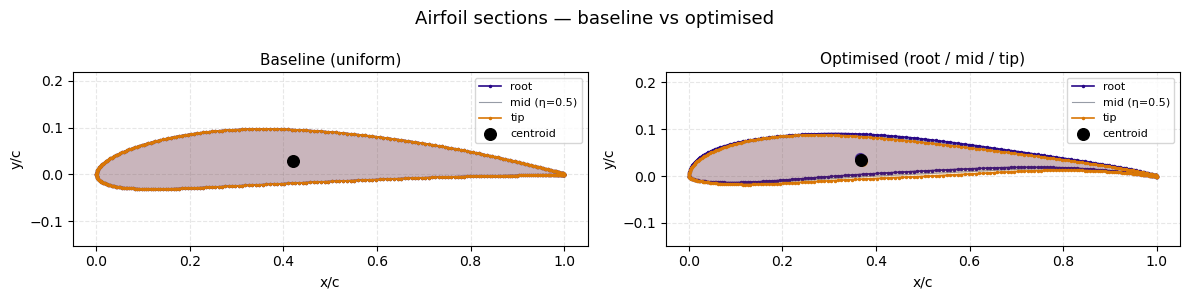

In [39]:
from aerosandbox import KulfanAirfoil
from glider_optimization.utils.spanwise_geometry import _section_centroid_from_kulfan

C_ROOT = "#280887"   # dark purple  (root)
C_TIP  = "#d97706"   # amber        (tip)
C_MID  = "#6b7280"   # grey         (midspan)

def _asb_airfoil(p_upper, p_lower, p_LE, p_TE):
    """Build KulfanAirfoil from numpy arrays / scalars."""
    return KulfanAirfoil(
        upper_weights=np.asarray(p_upper, dtype=float),
        lower_weights=np.asarray(p_lower, dtype=float),
        leading_edge_weight=float(p_LE),
        TE_thickness=float(p_TE),
    )

def _kulfan_dict(p_upper, p_lower, p_LE, p_TE):
    return dict(upper_weights=np.asarray(p_upper, dtype=float),
                lower_weights=np.asarray(p_lower, dtype=float),
                leading_edge_weight=float(p_LE),
                TE_thickness=float(p_TE))

def _get_sections(af: AirfoilParams):
    """Return (root, mid, tip) KulfanAirfoil objects from an AirfoilParams."""
    u_r = af.upper.detach().cpu().numpy()
    l_r = af.lower.detach().cpu().numpy()
    le_r = float(af.LE.detach().cpu())
    te_r = float(af.TE.detach().cpu())

    if af.upper_tip is not None:
        u_t  = af.upper_tip.detach().cpu().numpy()
        l_t  = af.lower_tip.detach().cpu().numpy()
        le_t = float(af.LE_tip.detach().cpu())
        te_t = float(af.TE_tip.detach().cpu())
    else:
        u_t, l_t, le_t, te_t = u_r, l_r, le_r, te_r

    u_m  = 0.5 * (u_r + u_t)
    l_m  = 0.5 * (l_r + l_t)
    le_m = 0.5 * (le_r + le_t)
    te_m = 0.5 * (te_r + te_t)

    root = _asb_airfoil(u_r, l_r, le_r, te_r)
    mid  = _asb_airfoil(u_m, l_m, le_m, te_m)
    tip  = _asb_airfoil(u_t, l_t, le_t, te_t)

    cx_r, cz_r = _section_centroid_from_kulfan(_kulfan_dict(u_r, l_r, le_r, te_r))
    cx_t, cz_t = _section_centroid_from_kulfan(_kulfan_dict(u_t, l_t, le_t, te_t))
    # Wing centroid: trapezoid-weighted mean (simplified — equal chord weight here)
    cx_w = 0.5 * (cx_r + cx_t)
    cz_w = 0.5 * (cz_r + cz_t)

    return root, mid, tip, (cx_r, cz_r), (cx_t, cz_t), (cx_w, cz_w)

def _plot_airfoil_panel(ax, af: AirfoilParams, title: str):
    root, mid, tip, (cx_r, cz_r), (cx_t, cz_t), (cx_w, cz_w) = _get_sections(af)

    x_r = np.asarray(root.x(), dtype=float).reshape(-1)
    y_r = np.asarray(root.y(), dtype=float).reshape(-1)
    x_m = np.asarray(mid.x(),  dtype=float).reshape(-1)
    y_m = np.asarray(mid.y(),  dtype=float).reshape(-1)
    x_t = np.asarray(tip.x(),  dtype=float).reshape(-1)
    y_t = np.asarray(tip.y(),  dtype=float).reshape(-1)

    ax.fill(x_r, y_r, color=C_ROOT, alpha=0.20, zorder=10)
    ax.plot(x_r, y_r, '.-', color=C_ROOT, linewidth=1.2, markersize=3, zorder=11, label='root')

    ax.fill(x_m, y_m, color=C_MID, alpha=0.10, zorder=8)
    ax.plot(x_m, y_m, '-',  color=C_MID,  linewidth=0.8, alpha=0.7, zorder=9, label='mid (η=0.5)')

    ax.fill(x_t, y_t, color=C_TIP, alpha=0.15, zorder=12)
    ax.plot(x_t, y_t, '.-', color=C_TIP, linewidth=1.2, markersize=3, zorder=13, label='tip')

    ax.scatter(cx_r, cz_r, color=C_ROOT, s=50, zorder=20, alpha=0.7)
    ax.scatter(cx_t, cz_t, color=C_TIP,  s=50, zorder=20, alpha=0.7)
    ax.scatter(cx_w, cz_w, color='black', s=70, zorder=21, label='centroid')

    ax.set_aspect(1.0, adjustable='datalim')
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.set(xlabel='x/c', ylabel='y/c')

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
_plot_airfoil_panel(axes[0], airfoil_base, 'Baseline (uniform)')
_plot_airfoil_panel(axes[1], airfoil_opt,  'Optimised (root / mid / tip)')
plt.suptitle('Airfoil sections — baseline vs optimised', fontsize=13)
plt.tight_layout(); plt.show()


### Optimised Kulfan parameters

Printed below in copy-pasteable form so they can be reused as warm-start weights or exported to a config.  
**Note:** the LLT used throughout this notebook is a *steady* nonlinear LLT — no time-stepping, no reduced-frequency correction, no unsteady wake history.


In [40]:
def _to_list(t):
    return [round(x, 8) for x in t.detach().cpu().numpy().tolist()]

def _f(t):
    return float(t.detach().cpu())

def _print_params(label, upper, lower, LE, TE):
    print(f"  # {label}")
    print(f"  upper_initial_weights: {_to_list(upper)}")
    print(f"  lower_initial_weights: {_to_list(lower)}")
    print(f"  leading_edge_weight: {_f(LE):.8f}")
    print(f"  TE_thickness: {_f(TE):.8f}")

print("# Optimised Kulfan weights  (copy-pasteable into test.yaml)\nairfoil:")
_print_params("root", airfoil_opt.upper, airfoil_opt.lower, airfoil_opt.LE, airfoil_opt.TE)
if airfoil_opt.upper_tip is not None:
    _print_params("tip",  airfoil_opt.upper_tip, airfoil_opt.lower_tip,
                  airfoil_opt.LE_tip, airfoil_opt.TE_tip)

# Also available as tensors for direct warm-starting:
#   new_af = AirfoilParams.from_yaml('../conf/test.yaml', wing.device)
#   with torch.no_grad():
#       new_af.upper.copy_(airfoil_opt.upper)
#       new_af.lower.copy_(airfoil_opt.lower)
#       new_af.upper_tip.copy_(airfoil_opt.upper_tip)
#       new_af.lower_tip.copy_(airfoil_opt.lower_tip)


# Optimised Kulfan weights  (copy-pasteable into test.yaml)
airfoil:
  # root
  upper_initial_weights: [0.26109743, 0.18541448, 0.26497892, 0.24473949, 0.19710974, 0.21053229, 0.16806713, 0.27598473]
  lower_initial_weights: [-0.08155926, -0.07834306, 0.03011858, 0.04112011, -0.02713892, 0.12551965, 0.10386757, 0.15730993]
  leading_edge_weight: 0.10444251
  TE_thickness: 0.00221918
  # tip
  upper_initial_weights: [0.22687715, 0.2095557, 0.28009972, 0.17961335, 0.18066733, 0.20135626, 0.15408874, 0.24230509]
  lower_initial_weights: [-0.08531188, -0.10644559, 0.01286, 0.02126654, -0.08130523, 0.08206793, 0.08172786, 0.14567478]
  leading_edge_weight: 0.11179683
  TE_thickness: 0.00221355


## 10 · Spanwise distributions — Γ, local cl, downwash

Evaluated at a representative cruise AoA (α = 5°, V = 10 m/s).  
Both halfspans shown; positive y = starboard.


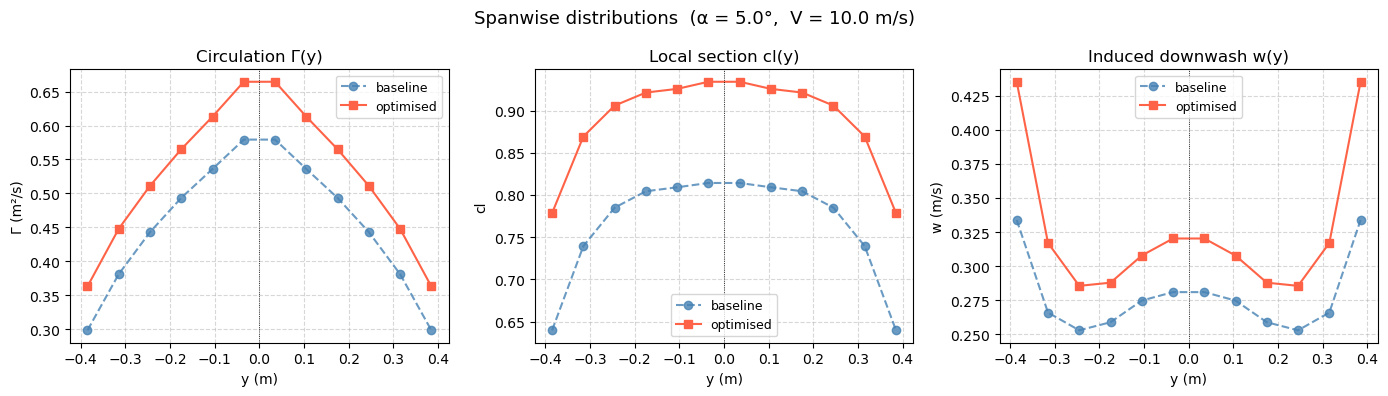

In [41]:
ALPHA_SPAN = 5.0   # deg — representative cruise AoA for spanwise plots
V_SPAN     = 10.0  # m/s

pan_base = evaluator.eval_spanwise(ALPHA_SPAN, V_SPAN, airfoil_base)
pan_opt  = evaluator.eval_spanwise(ALPHA_SPAN, V_SPAN, airfoil_opt)

y_b = pan_base["y"]
y_o = pan_opt["y"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# --- Circulation ---
axes[0].plot(y_b, pan_base["Gamma"], 'o--', color='steelblue', label='baseline', alpha=0.8)
axes[0].plot(y_o, pan_opt ["Gamma"], 's-',  color='tomato',    label='optimised')
axes[0].set(xlabel='y (m)', ylabel='Γ (m²/s)', title='Circulation Γ(y)')
axes[0].axvline(0, color='k', linewidth=0.6, linestyle=':')

# --- Local section cl ---
axes[1].plot(y_b, pan_base["cl_pan"], 'o--', color='steelblue', label='baseline', alpha=0.8)
axes[1].plot(y_o, pan_opt ["cl_pan"], 's-',  color='tomato',    label='optimised')
axes[1].set(xlabel='y (m)', ylabel='cl', title='Local section cl(y)')
axes[1].axvline(0, color='k', linewidth=0.6, linestyle=':')

# --- Induced downwash ---
axes[2].plot(y_b, pan_base["w_nf"], 'o--', color='steelblue', label='baseline', alpha=0.8)
axes[2].plot(y_o, pan_opt ["w_nf"], 's-',  color='tomato',    label='optimised')
axes[2].set(xlabel='y (m)', ylabel='w (m/s)', title='Induced downwash w(y)')
axes[2].axvline(0, color='k', linewidth=0.6, linestyle=':')

for ax in axes:
    ax.legend(fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.5)

plt.suptitle(f'Spanwise distributions  (α = {ALPHA_SPAN}°,  V = {V_SPAN} m/s)', fontsize=13)
plt.tight_layout(); plt.show()
